# Solar Filament Segmentation Challenge 2026
## U-Net + ConvNeXt training, evaluation, and inference

This notebook is the pipeline driver: it installs the extra deep-learning
dependencies, points the shared config at Kaggle's `/kaggle/input` mounts,
then calls the same `scripts/train.py` / `scripts/evaluate.py` / `scripts/infer.py`
used locally -- so the logic lives in one place (the code dataset attached to
this kernel), not duplicated into notebook cells.

**Task**: binary, category-agnostic filament segmentation (the competition's
Overview page states class labels are out of scope for scoring). A U-Net with a
ConvNeXt-Tiny encoder predicts a foreground probability map; watershed
post-processing splits it into individual filament instances for the
Panoptic-Quality-scored submission format.

### 0. Confirm the mounted data layout
Adjust `configs/config_kaggle.yaml`'s `data:` paths if this doesn't match.

In [19]:
!git clone https://github.com/jprakash-1/Solar-Filament-Segmentation.git

Cloning into 'Solar-Filament-Segmentation'...
remote: Enumerating objects: 225, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (159/159), done.
remote: Total 225 (delta 120), reused 162 (delta 60), pack-reused 0 (from 0)
Receiving objects: 100% (225/225), 1017.79 KiB | 11.44 MiB/s, done.
Resolving deltas: 100% (120/120), done.


In [3]:
%cd /kaggle/working/Solar-Filament-Segmentation
!ls

/kaggle/working/Solar-Filament-Segmentation
configs		 memory.md	   scripts
data		 outputs	   solar-filament-segmentation-analysis.ipynb
kaggle_notebook  README.md	   src
kaggle_package	 requirements.txt  state.db


In [4]:
!find /kaggle/input -maxdepth 3

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/filament-segmentation-2026
/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026


### 1. Bring in the code dataset and install missing dependencies

In [5]:
!git pull origin master 

remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 21 (delta 14), reused 17 (delta 10), pack-reused 0 (from 0)
Unpacking objects: 100% (21/21), 8.98 KiB | 1022.00 KiB/s, done.
From https://github.com/jprakash-1/Solar-Filament-Segmentation
 * branch            master     -> FETCH_HEAD
   457afce..69d5714  master     -> origin/master
Updating 457afce..69d5714
Fast-forward
 configs/config_kaggle.yaml |  41 +++++++++++-------
 memory.md                  | 103 ++++++++++++++++++++++++++++++++++++++-------
 scripts/train.py           |  21 +++++----
 3 files changed, 126 insertions(+), 39 deletions(-)


In [6]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [7]:
import torch
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))

torch 2.10.0+cu128
cuda available: True
device: Tesla T4


### 2. Train
`configs/config_kaggle.yaml` sets `image_size: 2048` (native resolution) and a GPU-sized
`batch_size` (default 4 -- raise/lower depending on VRAM). Override any config value
from the CLI, e.g. `--epochs` / `--batch-size`, without editing the file.

In [8]:
!torchrun --nproc_per_node=$(python -c "import torch; print(max(1, torch.cuda.device_count()))") \
    scripts/train.py --config configs/config_kaggle.yaml

W0822 17:09:37.627000 130 torch/distributed/run.py:852] 
W0822 17:09:37.627000 130 torch/distributed/run.py:852] *****************************************
W0822 17:09:37.627000 130 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0822 17:09:37.627000 130 torch/distributed/run.py:852] *****************************************
Using device: cuda:0 (DDP, world_size=2)
train images: 1039  val images: 115
Train augmentations: RandomResizedCrop -> HorizontalFlip -> VerticalFlip -> RandomRotate90 -> Affine -> RandomBrightnessContrast -> Normalize -> ToTensorV2
Val transforms:      Resize -> Normalize -> ToTensorV2
Batches per epoch: 260 train, 58 val (batch_size=2/rank, global=4, num_workers=4)
model.safetensors: 100%|█████████████████████| 201M/201M [00:03<00:00, 66.1MB/s]
Model: tu-convnext_small encod

### 3. Training curve

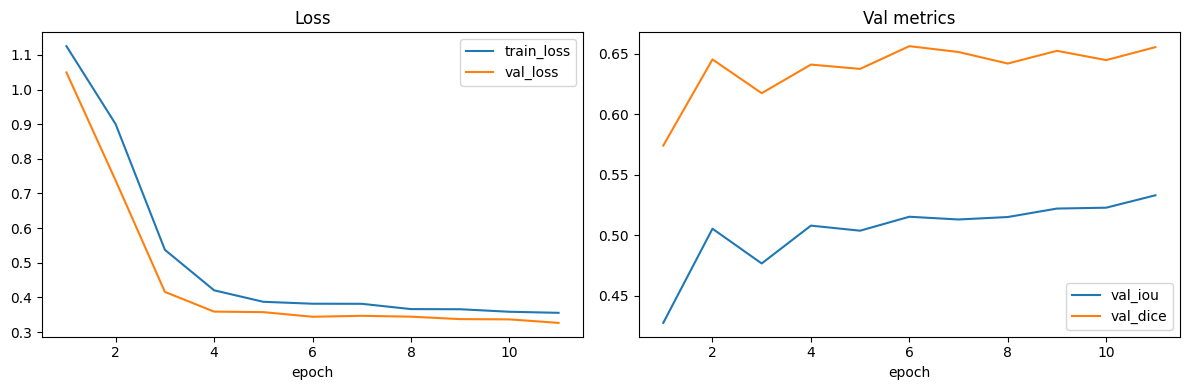

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


log = pd.read_csv('outputs/logs/20260822_171011_small_img1536_bs4_gc//train_log.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log['epoch'], log['train_loss'], label='train_loss')
axes[0].plot(log['epoch'], log['val_loss'], label='val_loss')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].set_title('Loss')
axes[1].plot(log['epoch'], log['val_iou'], label='val_iou')
axes[1].plot(log['epoch'], log['val_dice_torchmetrics'], label='val_dice')
axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].set_title('Val metrics')
fig.tight_layout()
plt.show()

### 4. Evaluate (instance-level Panoptic Quality + Dice)
Runs the full inference + post-processing pipeline against the held-out val split's
ground truth -- the same instance-splitting logic used for the actual submission --
as a local sanity check against the competition's real leaderboard metric.

In [12]:
!python scripts/evaluate.py --checkpoint outputs/checkpoints/20260822_171011_small_img1536_bs4_gc/best.pt  --sweep-watershed-min-distance "40,60,80,100,120,140"

Using device: cuda  (Tesla T4)
Evaluating on 115 val images (checkpoint epoch 6)
Sweep mode: will try watershed_min_distance in [40, 60, 80, 100, 120, 140] against cached predictions
sweep: 100%|█████████████████████████████████████| 6/6 [10:57<00:00, 109.60s/it]

  watershed_min_distance    mean PQ    pred/gt instances
                     140     0.3231              829/898
                     120     0.3202              917/898
                     100     0.3157             1004/898
                      80     0.3032             1123/898
                      60     0.2693             1297/898
                      40     0.2171             1589/898

Best: watershed_min_distance=140 (mean PQ=0.3231) -- computing full mAP for this config below.

Computing mAP@[.5:.95]: 829 predicted instances vs 898 ground-truth instances across 115 images, over 10 IoU thresholds -- this is the slow part (full-resolution mask matching), progress bar below.
mAP thresholds: 100%|████████████████████

### 5. Inference -> submission CSV
Predicts on the test set, splits into filament instances, RLE-encodes each one, and
writes `outputs/submissions/submission_<timestamp>.csv` in the exact
`filament_id,segmentation_rle` format the competition expects.

In [ ]:
!python scripts/infer.py --checkpoint outputs/checkpoints/20260822_143638_img1536_bs12_gc/best.pt --visualize 10

In [ ]:
import glob
import pandas as pd

submissions = sorted(glob.glob('outputs/submissions/*.csv'))
print('Latest submission:', submissions[-1] if submissions else 'none found')
pd.read_csv(submissions[-1]).head()

### 6. Spot-check a few predictions

In [ ]:
import glob
from PIL import Image

for path in sorted(glob.glob('outputs/eda/predictions/*.png'))[:3]:
    display(Image.open(path))

### 7. Compare predictions vs ground truth on the training set
Qualitative sanity check, distinct from section 4 (held-out val-set metrics) and section 5
(ground-truth-less test-set predictions): runs on all 1039 training-set images and plots
input | ground truth | predicted side by side, using the tuned `watershed_min_distance=140`.
`--n -1` means all images -- this is slow (one GPU forward pass + watershed per image, ~1039
images); pass e.g. `--n 6` instead for a quick spot-check on a random sample.

In [ ]:
!python scripts/visualize_train_predictions.py --checkpoint outputs/checkpoints/best.pt \
    --n -1 --watershed-min-distance 140

In [ ]:
import glob
from PIL import Image

for path in sorted(glob.glob('outputs/train_samples_predictions/*.png')):
    display(Image.open(path))

Zip the comparison plots for download (`kaggle kernels output` after committing this run, or via the **Output** tab).

In [ ]:
!zip -r train_samples_predictions.zip outputs/train_samples_predictions

### Outputs
- `outputs/checkpoints/best.pt` / `last.pt` -- model weights
- `outputs/logs/train_log.csv` -- per-epoch metrics
- `outputs/submissions/submission_*.csv` -- ready to submit to the competition
- `outputs/eda/predictions/*.png` -- qualitative overlays (test set, no ground truth)
- `outputs/train_samples_predictions/*.png` -- input/ground-truth/predicted comparisons on
  training-set samples (also zipped to `train_samples_predictions.zip`)

All of the above persist as this notebook's **Output** after a committed run,
downloadable via `kaggle kernels output <username>/filament-unet-convnext-training -p <local-dir>`.

In [ ]:
!ls

In [ ]:
%cd ..

In [ ]:
!zip -r  checkpoints.zip checkpoints

In [ ]:
!zip -r outputs.zip outputs/